# Machine Learning to Identify Premier League BTTS Betting Opportunities - Gameweek 37

In [1]:
from process import create_datasets, get_fixtures
from utils import convert_btts_odds_to_probability, get_results
from neural_network import NeuralNetwork
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import seaborn as sns
import numpy as np
import pandas as pd
import torch

Start by importing match and betting data and generate training and testing datasets. In this notebook we are going to try to identify Both Teams to Score (BTTS) betting opportunities for the final gameweek of the season. We will use the matches from gameweeks six to 36 as the training data. Each training sample consists of 10 features. For each fixture in a particular gameweek we collect: total goals scored, total expected goals, total expected goals against, and total goals conceded for both teams in the fixture, home factor (scored minus conceded in the home team's previous home games), and away factor (scored minus conceded in the away team's previous away games). These features are only collected over the previous 3 gameweeks as we are going to prioritse recent form and performance.

In [2]:
match_data = pd.read_csv("data/processed.csv")
odds_data = pd.read_csv("data/betting_odds.csv")

X_train, y_train, X_test, y_test = create_datasets(match_data, 4, 36, prev_games=3)
 
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test)

C:\Users\marti\AppData\Local\Temp\ipykernel_6632\1269295821.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.from_numpy(y_train)


We will take a look at the correation matrix of the features to ensure that any multicollinearity present is not excessive. 

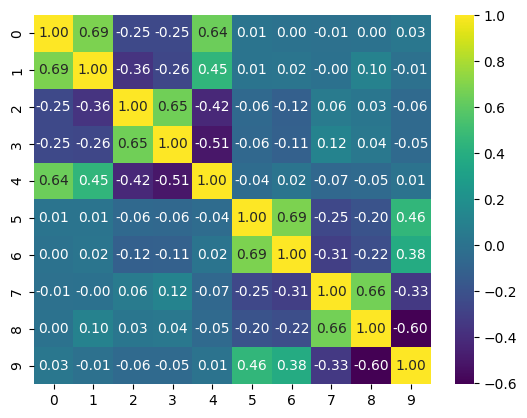

In [3]:
img = sns.heatmap(np.cov(X_train.T), cmap="viridis", annot=True, fmt=".2f")

Now we will take a look at the final gameweek of fixtures and their BTTS odds and probabilities. These are the fixtures for which we will try to identify opportunities for BTTS betting.

In [4]:
final_fixtures = get_fixtures(match_data, 37)

home_teams = []
away_teams = []
btts_yes = []
btts_no = []

for home, away in final_fixtures:
    home_teams.append(home)
    away_teams.append(away)
    home_odds_df = odds_data[odds_data["homeTeam"] == home]
    match_row = home_odds_df[home_odds_df["awayTeam"] == away]
    btts_yes.append(match_row["BTTSY"].item())
    btts_no.append(match_row["BTTSN"].item())

final_fixtures_df = pd.DataFrame({"Home": home_teams, "Away": away_teams, "btts yes": btts_yes,
                                  "btts no": btts_no})
final_fixtures_df["btts_yes_prob"] = final_fixtures_df.apply(lambda row: convert_btts_odds_to_probability(row["btts yes"]), axis=1)
final_fixtures_df["btts_no_prob"] = final_fixtures_df.apply(lambda row: convert_btts_odds_to_probability(row["btts no"]), axis=1)
final_fixtures_df = final_fixtures_df.round(3)
final_fixtures_df.head(10)

,Home,Away,btts yes,btts no,btts_yes_prob,btts_no_prob
0,Aston Villa,Tottenham,1.68,2.18,0.595,0.459
1,Chelsea,Manchester United,1.60,2.34,0.625,0.427
2,Everton,Southampton,1.90,1.90,0.526,0.526
3,West Ham,Nottingham Forest,1.72,2.12,0.581,0.472
4,Brentford,Fulham,1.57,2.42,0.637,0.413
5,Leicester,Ipswich,1.57,2.41,0.637,0.415
6,Arsenal,Newcastle United,1.59,2.36,0.629,0.424
7,Brighton,Liverpool,1.43,2.82,0.699,0.355
8,Crystal Palace,Wolves,1.68,2.18,0.595,0.459
9,Manchester City,Bournemouth,1.76,2.06,0.568,0.485


## Neural Network

The first model we will train is a simple neural network with two hidden layers and a softmax final layer which will output BTTS yes and BTTS no probabilities. The neural network will be trained over 30 epochs and is regularised. 

In [5]:
neural_net = NeuralNetwork(features=10, hidden_one=32, hidden_two=32)
neural_net.generate()
neural_net.configure()
neural_net.train(30, X_train, y_train)
predicted_odds_nn = neural_net.predict(X_test)

final_fixtures_df["btts yes prob nn"] = [i.item() for i in predicted_odds_nn]

## Logistic Regression 

The second model we will train is a very basic logistic regression model, which will output the predicted probabilities for BTTS yes and BTTS no. 

In [6]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
predicted_odds_logreg = logreg.predict_proba(X_test)

final_fixtures_df["btts yes prob logreg"] = [i[1].item() for i in predicted_odds_logreg]

## XGBoost

The final model will be a very basic implementation of the XGBoost algorithm, which utilises gradient boosted decision trees. Again, the output will be the probabilities for BTTS yes and BTTS no.

In [7]:
xgb_data_train = xgb.DMatrix(X_train, label=y_train)
xgb_data_test = xgb.DMatrix(X_test)

xgb_params = {"objective": "binary:logistic"}
trained = xgb.train(xgb_params, xgb_data_train, num_boost_round=10)
predicted_odds_xgb = trained.predict(xgb_data_test)

final_fixtures_df["btts yes prob xgb"] = predicted_odds_xgb

Now let's view the final gameweek's fixtures along with the bookmakers BTTS odds and our calcaulated BTTS probabilities. The ensemble probbility is simply the mean of our three model probabilities.

In [8]:
final_fixtures_df["btts yes prob ensemble"] = (final_fixtures_df["btts yes prob nn"] + final_fixtures_df["btts yes prob logreg"] +
                                               final_fixtures_df["btts yes prob xgb"])/3
final_fixtures_df = final_fixtures_df.round(3)
final_fixtures_df.head(10)

,Home,Away,btts yes,btts no,btts_yes_prob,btts_no_prob,btts yes prob nn,btts yes prob logreg,btts yes prob xgb,btts yes prob ensemble
0,Aston Villa,Tottenham,1.68,2.18,0.595,0.459,0.579,0.633,0.823,0.679
1,Chelsea,Manchester United,1.60,2.34,0.625,0.427,0.640,0.572,0.644,0.619
2,Everton,Southampton,1.90,1.90,0.526,0.526,0.644,0.578,0.740,0.654
3,West Ham,Nottingham Forest,1.72,2.12,0.581,0.472,0.624,0.598,0.304,0.509
4,Brentford,Fulham,1.57,2.42,0.637,0.413,0.568,0.557,0.528,0.551
5,Leicester,Ipswich,1.57,2.41,0.637,0.415,0.609,0.758,0.933,0.766
6,Arsenal,Newcastle United,1.59,2.36,0.629,0.424,0.607,0.605,0.882,0.698
7,Brighton,Liverpool,1.43,2.82,0.699,0.355,0.635,0.617,0.669,0.640
8,Crystal Palace,Wolves,1.68,2.18,0.595,0.459,0.666,0.733,0.574,0.657
9,Manchester City,Bournemouth,1.76,2.06,0.568,0.485,0.557,0.558,0.453,0.523


To identify fixtures to place a BTTS yes bet on we are looking for the fixtures for which btts yes prob ensemble - btts yes is positive and large. Therefore we would choose to place bets on Aston Villa vs Totenham, Everton vs Southampton, Leicester vs Ipswich, Arsenal vs Newcastle United, and Crystal Palace vs Wolves.

In [9]:
get_results(match_data, gameweek=37)

,home team,home score,away score,away team,btts
0,Aston Villa,2,0,Tottenham,False
1,Chelsea,1,0,Manchester United,False
2,Everton,2,0,Southampton,False
3,West Ham,1,2,Nottingham Forest,True
4,Brentford,2,3,Fulham,True
5,Leicester,2,0,Ipswich,False
6,Arsenal,0,0,Newcastle United,False
7,Brighton,3,2,Liverpool,True
8,Crystal Palace,4,2,Wolves,True
9,Manchester City,3,1,Bournemouth,True


Consulting the results, we see that only one of our BTTS bets would have won.